# Phase 1: Clinical Data Cleansing & Exploratory Insight

## Project: Advanced Health Analytics & Readmission Prediction

This notebook focuses on the initial 'dirty work' of the clinical data pipeline:
1. **Data Ingestion**: Loading the synthetic EHR dataset.
2. **Cleansing**: Handling missing timestamps (Admission Dates) and clinical values (Hemoglobin).
3. **Outlier Detection**: Identifying and handling clinical anomalies in Blood Pressure and Glucose.
4. **Initial EDA**: Understanding the distribution of risk factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

### 1. Data Ingestion
We load the dataset generated by our `generate_clinical_data.py` script.

In [2]:
data_path = "../data/raw/synthetic_clinical_data.csv"
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (12000, 12)


,Patient_ID,Age,Gender,Admission_Date,Stay_Duration_Days,Discharge_Date,Systolic_BP,Glucose_mgdL,Hemoglobin_gdL,Diabetes,Hypertension,Readmitted_30Days
0,4174,52,M,2023-02-24 18:00:00,4,2023-02-28 18:00:00,129.902262,83.451331,11.924978,0,1,0
1,4507,60,F,2023-03-29 22:00:00,12,2023-04-10 22:00:00,117.894143,112.484035,11.000122,0,0,1
2,1860,69,M,2023-04-27 09:00:00,10,2023-05-07 09:00:00,110.722003,91.293780,15.557175,0,0,1
3,2294,70,M,2023-05-30 06:00:00,2,2023-06-01 06:00:00,109.521926,126.384367,9.775617,0,0,1
4,2130,65,F,2023-07-27 02:00:00,6,2023-08-02 02:00:00,134.054957,460.000000,11.796836,1,0,1


### 2. Handling Missing Values
In clinical settings, missing data can be 'Missing at Random' (MAR) or 'Missing Not at Random' (MNAR). 

- **Admission_Date**: Critical for time-series analysis. If missing, we may need to discard or infer if possible.
- **Hemoglobin_gdL**: Lab values can be missing due to test omission.

In [3]:
print("Missing Values Summary:")
print(df.isnull().sum())

# Strategy: Drop records with missing Admission Dates as they are fundamental timestamps
df_clean = df.dropna(subset=['Admission_Date']).copy()

# Strategy: Impute Hemoglobin with the median (robust to outliers)
df_clean['Hemoglobin_gdL'] = df_clean['Hemoglobin_gdL'].fillna(df_clean['Hemoglobin_gdL'].median())

print(f"\nShape after missing value handling: {df_clean.shape}")

Missing Values Summary:
Patient_ID              0
Age                     0
Gender                  0
Admission_Date        120
Stay_Duration_Days      0
Discharge_Date          0
Systolic_BP             0
Glucose_mgdL            0
Hemoglobin_gdL        600
Diabetes                0
Hypertension            0
Readmitted_30Days       0
dtype: int64

Shape after missing value handling: (11880, 12)


### 3. Outlier Detection (Vital Signs)
We use the Interquartile Range (IQR) and clinical knowledge to identify anomalies.

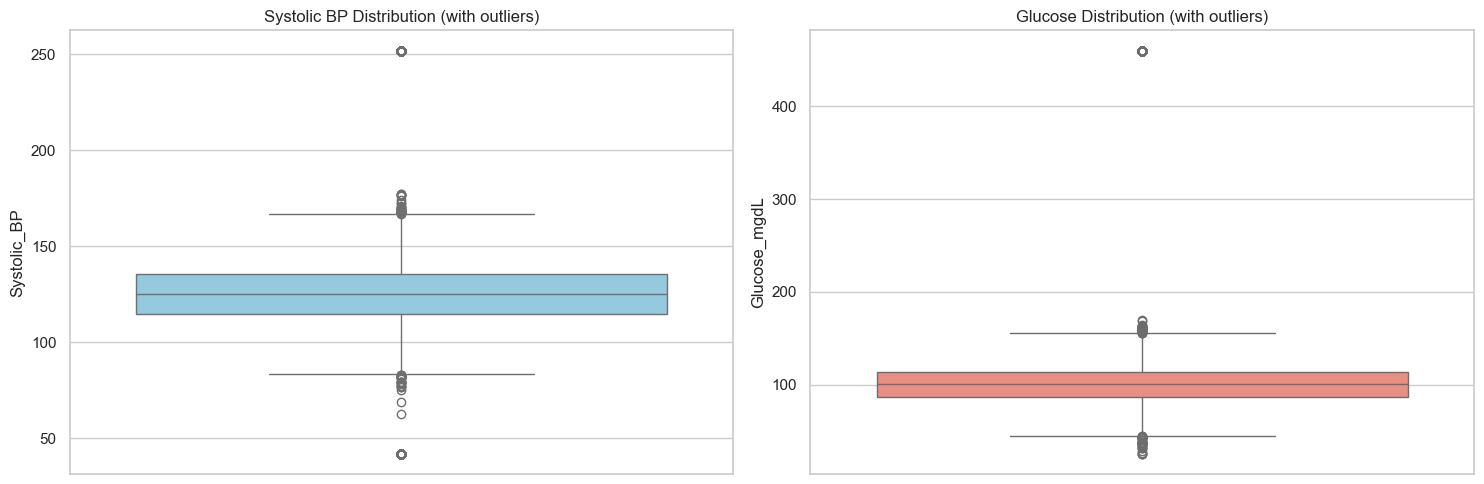

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(y=df_clean['Systolic_BP'], ax=ax[0], color='skyblue')
ax[0].set_title('Systolic BP Distribution (with outliers)')

sns.boxplot(y=df_clean['Glucose_mgdL'], ax=ax[1], color='salmon')
ax[1].set_title('Glucose Distribution (with outliers)')

plt.tight_layout()
plt.show()

### 4. Outlier Treatment Strategy
We use **Winsorization** to cap values at clinical and statistical thresholds. This prevents extreme values from skewing the model while retaining all patient records.

- **Systolic BP**: Cap at [60, 220] mmHg.
- **Glucose**: Cap at [40, 400] mg/dL.

In [5]:
def treat_outliers(df, column, lower_limit, upper_limit):
    """Applies capping (Winsorization) to a specific column."""
    df[column] = df[column].clip(lower=lower_limit, upper=upper_limit)
    return df

# Apply treatment based on clinical guidelines
df_clean = treat_outliers(df_clean, 'Systolic_BP', 60, 220)
df_clean = treat_outliers(df_clean, 'Glucose_mgdL', 40, 400)

print("Outlier treatment complete.")

Outlier treatment complete.


### 5. Verification: Post-Treatment Distributions
Let's verify that the extreme tails have been successfully capped.

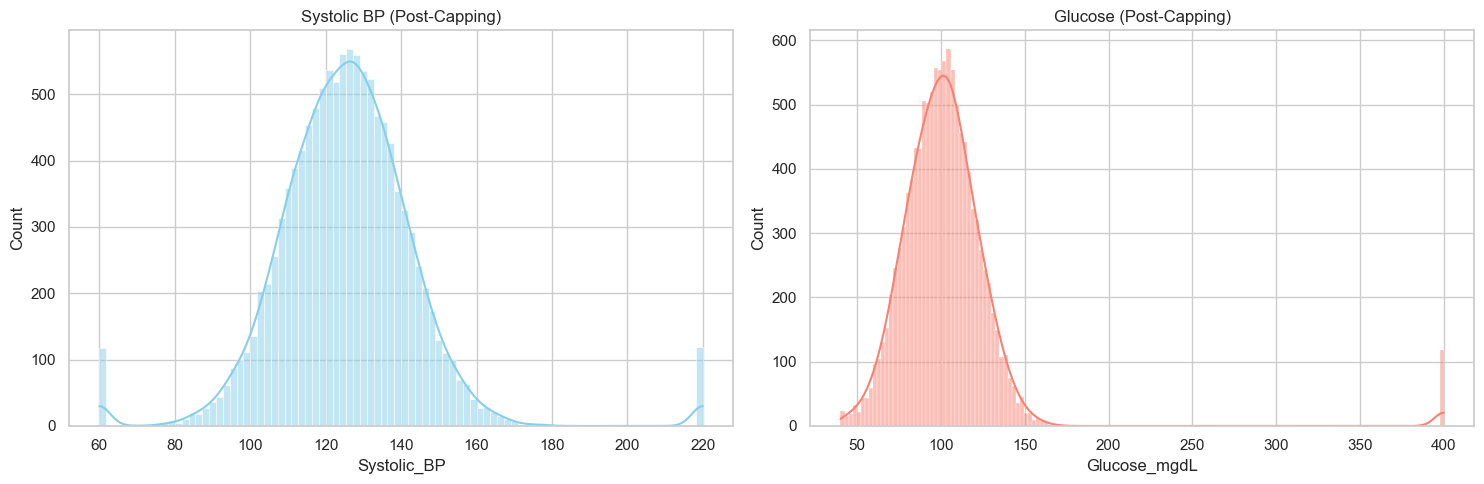

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean['Systolic_BP'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Systolic BP (Post-Capping)')

sns.histplot(df_clean['Glucose_mgdL'], kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Glucose (Post-Capping)')

plt.tight_layout()
plt.show()